<a href="https://colab.research.google.com/github/daari-git/Fault-Detection-Using-SVM/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing dataset

In [2]:
data  = pd.read_csv('classData.csv')
print(data)

      G  C  B  A          Ia          Ib          Ic        Va        Vb  \
0     1  0  0  1 -151.291812   -9.677452   85.800162  0.400750 -0.132935   
1     1  0  0  1 -336.186183  -76.283262   18.328897  0.312732 -0.123633   
2     1  0  0  1 -502.891583 -174.648023  -80.924663  0.265728 -0.114301   
3     1  0  0  1 -593.941905 -217.703359 -124.891924  0.235511 -0.104940   
4     1  0  0  1 -643.663617 -224.159427 -132.282815  0.209537 -0.095554   
...  .. .. .. ..         ...         ...         ...       ...       ...   
7856  0  0  0  0  -66.237921   38.457041   24.912239  0.094421 -0.552019   
7857  0  0  0  0  -65.849493   37.465454   25.515675  0.103778 -0.555186   
7858  0  0  0  0  -65.446698   36.472055   26.106554  0.113107 -0.558211   
7859  0  0  0  0  -65.029633   35.477088   26.684731  0.122404 -0.561094   
7860  0  0  0  0  -64.598401   34.480799   27.250065  0.131669 -0.563835   

            Vc  
0    -0.267815  
1    -0.189099  
2    -0.151428  
3    -0.130570  
4 

# Decoding the data to fault Type

In [3]:
data['Fault'] = data[['G', 'C', 'B', 'A']].apply(lambda row: ''.join(row.astype(str)), axis=1)

# Definig the Input & Output also sperating into Independent Values &Dependent values

In [4]:
X = data[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']] #Input all Current and Voltage value
y = data['Fault'] # Output as fault type.

# Normalization

In [5]:
from sklearn.preprocessing import StandardScaler
scalling = StandardScaler()
X_scalled = scalling.fit_transform(X)

# Spliting data into train and test set

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train an SVM classifier

In [7]:
from sklearn.svm import SVC
model = SVC(kernel='rbf', gamma=0.0001, C=10)
model.fit(X_train, y_train)

SVC(C=10, gamma=0.0001)

# Evaluate the model

## Model Evalution On the basic of Confusion Matrix

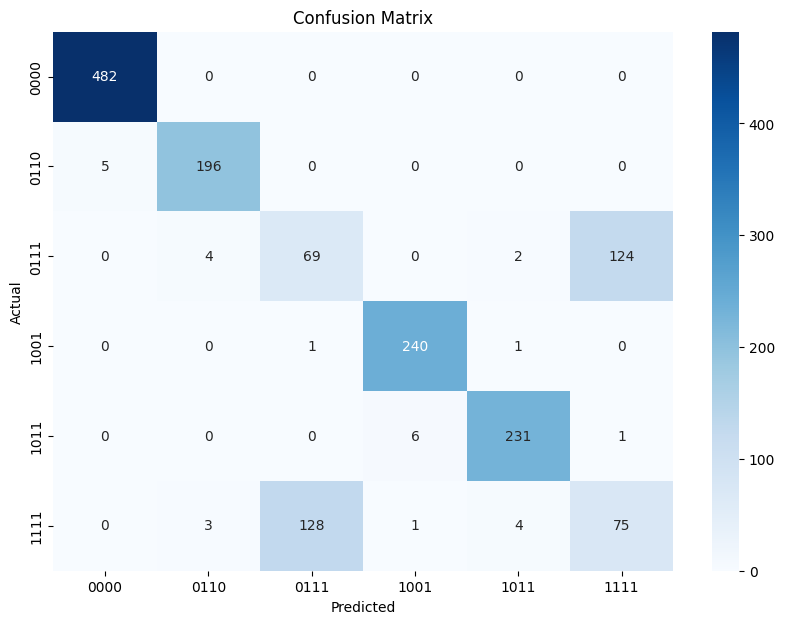

In [8]:
# Compute and display the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Model Evalution on F1 score, Accuracy

In [9]:
from sklearn.metrics import classification_report
print("Model Evaluation:")
print(classification_report(y_test, y_pred))

Model Evaluation:
              precision    recall  f1-score   support

        0000       0.99      1.00      0.99       482
        0110       0.97      0.98      0.97       201
        0111       0.35      0.35      0.35       199
        1001       0.97      0.99      0.98       242
        1011       0.97      0.97      0.97       238
        1111       0.38      0.36      0.36       211

    accuracy                           0.82      1573
   macro avg       0.77      0.77      0.77      1573
weighted avg       0.82      0.82      0.82      1573

